In [1]:
import sys
import pandas as pd
import numpy as np
import torch
from prophet import Prophet
from huggingface_hub import hf_hub_download
from prophet.data.dataloader import read_in_priors
import pandas as pd
import os

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Check matched_drugs structure
matched = pd.read_csv("matched_drugs.csv")
print("matched_drugs columns:", matched.columns.tolist())
matched.head(3)

matched_drugs columns: ['drug', 'smiles', 'drug_norm', 'smiles_norm', 'match_name', 'match_smiles', 'datasets', 'chembl_id', 'chembl_smiles']


,drug,smiles,drug_norm,smiles_norm,match_name,match_smiles,datasets,chembl_id,chembl_smiles
0,Osimertinib,C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(O...,osimertinib,c=cc(=o)nc1cc(nc2nccc(-c3cn(c)c4ccccc34)n2)c(o...,True,True,"GDSC, PRISM",CHEMBL3353410,C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(O...
1,Trametinib,CC(=O)Nc1cccc(c1)-n1c2c(C)c(=O)n(C)c(Nc3ccc(I)...,trametinib,cc(=o)nc1cccc(c1)-n1c2c(c)c(=o)n(c)c(nc3ccc(i)...,True,False,"CTRP, GDSC, GDSCcomb, LINCS, PRISM",CHEMBL2103875,CC(=O)Nc1cccc(-n2c(=O)n(C3CC3)c(=O)c3c(Nc4ccc(...
2,Paclitaxel,CC(=O)O[C@@H]1C2=C(C)[C@H](C[C@@](O)([C@@H](OC...,paclitaxel,cc(=o)o[c@@h]1c2=c(c)[c@h](c[c@@](o)([c@@h](oc...,True,False,"CTRP, GDSC, GDSCcomb, LINCS, PRISM",CHEMBL428647,CC(=O)O[C@H]1C(=O)[C@@]2(C)[C@H]([C@H](OC(=O)c...


In [32]:
matched["smiles_norm"] = matched["smiles_norm"].str.strip().str.lower()
smiles_set = set(matched["smiles_norm"].dropna())
dataset_files = ["LINCS", "CTRP", "PRISM", "GDSCcomb", "GDSC", "JUMPsm"]
smiles_datasets = [f"{file}_dataset.csv" for file in dataset_files]
drug_set = set(matched["drug_norm"].dropna())
smiles_set = set(matched["smiles_norm"].dropna())

In [33]:
for file in smiles_datasets:
    df = pd.read_csv(f"datasets/{file}", nrows=3)
    has_iv_name = "iv_name" in df.columns
    print(f"{file:<30} iv_name: {has_iv_name}")

LINCS_dataset.csv              iv_name: False
CTRP_dataset.csv               iv_name: True
PRISM_dataset.csv              iv_name: True
GDSCcomb_dataset.csv           iv_name: True
GDSC_dataset.csv               iv_name: True
JUMPsm_dataset.csv             iv_name: False


In [34]:
name_datasets = ["CTRP", "PRISM", "GDSCcomb", "GDSC"]
smiles_only_datasets = ["LINCS", "JUMPsm"]
drug_to_datasets = {d: [] for d in drug_set}
smiles_to_datasets = {s: [] for s in smiles_set}

In [35]:
for dataset_name in name_datasets:
    df = pd.read_csv(f"datasets/{dataset_name}_dataset.csv", usecols=["iv_name"])
    unique_names = set(df["iv_name"].str.strip().str.lower().dropna().unique())
    for drug in drug_set:
        if drug in unique_names:
            drug_to_datasets[drug].append(dataset_name)
    print(f"Loaded {dataset_name} (by name)")

Loaded CTRP (by name)
Loaded PRISM (by name)
Loaded GDSCcomb (by name)
Loaded GDSC (by name)


In [36]:
for dataset_name in smiles_only_datasets:
    df = pd.read_csv(f"datasets/{dataset_name}_dataset.csv", usecols=["iv1"])
    unique_smiles = set(df["iv1"].str.strip().str.lower().dropna().unique())
    for smiles in smiles_set:
        if smiles in unique_smiles:
            smiles_to_datasets[smiles].append(dataset_name)
    print(f"Loaded {dataset_name} (by smiles)")

Loaded LINCS (by smiles)
Loaded JUMPsm (by smiles)


In [37]:
def get_datasets(row):
    datasets = drug_to_datasets.get(row["drug_norm"], []) + smiles_to_datasets.get(row["smiles_norm"], [])
    return ", ".join(sorted(set(datasets))) if datasets else "not found"

In [38]:
matched["datasets"] = matched.apply(get_datasets, axis=1)

In [46]:
for file in dataset_files:
    df = pd.read_csv(f"datasets/{file}_dataset.csv", usecols=["value"])
    desc = df["value"].describe()
    print(f"\n{file}")
    print(f"  min: {desc['min']:.3f}  max: {desc['max']:.3f}  mean: {desc['mean']:.3f}")


LINCS
  min: 0.000  max: 1.000  mean: 0.077

CTRP
  min: 0.000  max: 1.000  mean: 0.925

PRISM
  min: 0.000  max: 1.000  mean: 0.638

GDSCcomb
  min: 0.000  max: 1.000  mean: 0.542

GDSC
  min: 0.000  max: 1.000  mean: 0.513

JUMPsm
  min: 0.002  max: 0.995  mean: 0.401


In [47]:
import requests

def fetch_chembl_id(drug_name, smiles):
    # Try by name first
    url = f"https://www.ebi.ac.uk/chembl/api/data/molecule/search.json?q={drug_name}&limit=1"
    r = requests.get(url)
    if r.status_code == 200:
        mols = r.json().get("molecules", [])
        if mols:
            return mols[0]["molecule_chembl_id"]
    
    # Fallback: try by SMILES
    url = f"https://www.ebi.ac.uk/chembl/api/data/molecule.json?molecule_structures__canonical_smiles={smiles}&limit=1"
    r = requests.get(url)
    if r.status_code == 200:
        mols = r.json().get("molecules", [])
        if mols:
            return mols[0]["molecule_chembl_id"]
    
    return None

matched["chembl_id"] = matched["chembl_id"].astype(object)
for idx, row in matched[matched["chembl_id"].isna()].iterrows():
    chembl_id = fetch_chembl_id(row["drug"], row["smiles"])
    matched.at[idx, "chembl_id"] = chembl_id
    print(f"{row['drug']} -> {chembl_id}")

print(f"Drugs with chembl_id: {matched['chembl_id'].notna().sum()} / {len(matched)}")

,drug,smiles,drug_norm,smiles_norm,match_name,match_smiles,datasets
0,Osimertinib,C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(O...,osimertinib,c=cc(=o)nc1cc(nc2nccc(-c3cn(c)c4ccccc34)n2)c(o...,True,True,"GDSC, PRISM"
1,Trametinib,CC(=O)Nc1cccc(c1)-n1c2c(C)c(=O)n(C)c(Nc3ccc(I)...,trametinib,cc(=o)nc1cccc(c1)-n1c2c(c)c(=o)n(c)c(nc3ccc(i)...,True,False,"CTRP, GDSC, GDSCcomb, LINCS, PRISM"
2,Paclitaxel,CC(=O)O[C@@H]1C2=C(C)[C@H](C[C@@](O)([C@@H](OC...,paclitaxel,cc(=o)o[c@@h]1c2=c(c)[c@h](c[c@@](o)([c@@h](oc...,True,False,"CTRP, GDSC, GDSCcomb, LINCS, PRISM"
3,Docetaxel,CC(=O)O[C@]12CO[C@@H]1C[C@H](O)[C@]1(C)[C@@H]2...,docetaxel,cc(=o)o[c@]12co[c@@h]1c[c@h](o)[c@]1(c)[c@@h]2...,True,False,"CTRP, GDSC, GDSCcomb, LINCS, PRISM"
4,Palbociclib,CC(=O)c1c(C)c2cnc(Nc3ccc(cn3)N3CCNCC3)nc2n(C2C...,palbociclib,cc(=o)c1c(c)c2cnc(nc3ccc(cn3)n3ccncc3)nc2n(c2c...,True,False,"GDSC, GDSCcomb, LINCS, PRISM"
...,...,...,...,...,...,...,...
311,Ki8751,COc1cc2nccc(Oc3ccc(NC(=O)Nc4ccc(F)cc4F)c(F)c3)...,ki8751,coc1cc2nccc(oc3ccc(nc(=o)nc4ccc(f)cc4f)c(f)c3)...,True,False,"CTRP, LINCS"
312,ABT-737,CN(C)CC[C@H](CSc1ccccc1)Nc1ccc(cc1[N+]([O-])=O...,abt-737,cn(c)cc[c@h](csc1ccccc1)nc1ccc(cc1[n+]([o-])=o...,True,False,"CTRP, LINCS, PRISM"
313,GSK1059615,O=C1NC(=O)\C(S1)=C\c1ccc2nccc(-c3ccncc3)c2c1,gsk1059615,o=c1nc(=o)\c(s1)=c\c1ccc2nccc(-c3ccncc3)c2c1,True,False,CTRP
314,momelotinib,O=C(NCC#N)c1ccc(cc1)-c1ccnc(Nc2ccc(cc2)N2CCOCC...,momelotinib,o=c(ncc#n)c1ccc(cc1)-c1ccnc(nc2ccc(cc2)n2ccocc...,True,False,"CTRP, LINCS"


In [55]:
from chembl_webresource_client.new_client import new_client
import time

molecule = new_client.molecule

def fetch_chembl_info(drug_name, smiles):
    # Try by name
    results = molecule.filter(pref_name__iexact=drug_name.upper())
    if results:
        chembl_smiles = results[0].get("molecule_structures") or {}
        return results[0]["molecule_chembl_id"], chembl_smiles.get("canonical_smiles")
    
    # Fallback by SMILES
    results = molecule.filter(molecule_structures__canonical_smiles=smiles)
    if results:
        chembl_smiles = results[0].get("molecule_structures") or {}
        return results[0]["molecule_chembl_id"], chembl_smiles.get("canonical_smiles")
    
    return None, None

matched["chembl_id"] = None
matched["chembl_smiles"] = None

for idx, row in matched.iterrows():
    chembl_id, chembl_smiles = fetch_chembl_info(row["drug"], row["smiles"])
    matched.at[idx, "chembl_id"] = chembl_id
    matched.at[idx, "chembl_smiles"] = chembl_smiles
    
    # Compare SMILES
    match = "✓" if row["smiles"] == chembl_smiles else "✗"
    print(f"{row['drug']:<20} {match} chembl_id: {chembl_id}")
    if row["smiles"] != chembl_smiles:
        print(f"  ours:   {row['smiles'][:80]}")
        print(f"  chembl: {str(chembl_smiles)[:80]}")

print(f"\nDrugs with chembl_id:    {matched['chembl_id'].notna().sum()} / {len(matched)}")
print(f"Exact SMILES match:      {(matched['smiles'] == matched['chembl_smiles']).sum()} / {len(matched)}")
matched.to_csv("matched_drugs.csv", index=False)

Osimertinib          ✓ chembl_id: CHEMBL3353410
Trametinib           ✗ chembl_id: CHEMBL2103875
  ours:   CC(=O)Nc1cccc(c1)-n1c2c(C)c(=O)n(C)c(Nc3ccc(I)cc3F)c2c(=O)n(C2CC2)c1=O
  chembl: CC(=O)Nc1cccc(-n2c(=O)n(C3CC3)c(=O)c3c(Nc4ccc(I)cc4F)n(C)c(=O)c(C)c32)c1
Paclitaxel           ✗ chembl_id: CHEMBL428647
  ours:   CC(=O)O[C@@H]1C2=C(C)[C@H](C[C@@](O)([C@@H](OC(=O)c3ccccc3)C3[C@@]4(CO[C@@H]4C[C
  chembl: CC(=O)O[C@H]1C(=O)[C@@]2(C)[C@H]([C@H](OC(=O)c3ccccc3)[C@]3(O)C[C@H](OC(=O)[C@H]
Docetaxel            ✗ chembl_id: CHEMBL3545252
  ours:   CC(=O)O[C@]12CO[C@@H]1C[C@H](O)[C@]1(C)[C@@H]2[C@H](OC(=O)c2ccccc2)[C@]2(O)C[C@@
  chembl: CC(=O)O[C@@]12CO[C@@H]1C[C@H](O)[C@@]1(C)C(=O)[C@H](O)C3=C(C)[C@@H](OC(=O)[C@H](
Palbociclib          ✗ chembl_id: CHEMBL189963
  ours:   CC(=O)c1c(C)c2cnc(Nc3ccc(cn3)N3CCNCC3)nc2n(C2CCCC2)c1=O
  chembl: CC(=O)c1c(C)c2cnc(Nc3ccc(N4CCNCC4)cn3)nc2n(C2CCCC2)c1=O
Dabrafenib           ✗ chembl_id: CHEMBL2028663
  ours:   CC(C)(C)c1nc(c(s1)-c1ccnc(N)n1)-c1cccc(NS(=O

In [59]:
from rdkit import Chem

def same_molecule(smiles1, smiles2):
    if pd.isna(smiles1) or pd.isna(smiles2):
        return False
    mol1 = Chem.MolFromSmiles(smiles1)
    mol2 = Chem.MolFromSmiles(smiles2)
    if mol1 is None or mol2 is None:
        return False
    return Chem.MolToSmiles(mol1) == Chem.MolToSmiles(mol2)

matched["same_molecule"] = matched.apply(
    lambda row: same_molecule(row["smiles"], row["chembl_smiles"]), axis=1
)

print(f"Same molecule (canonical match): {matched['same_molecule'].sum()} / {len(matched)}")
print(matched[~matched["same_molecule"]][["drug", "smiles", "chembl_smiles"]].head(10))

Same molecule (canonical match): 223 / 316
            drug                                             smiles  \
2     Paclitaxel  CC(=O)O[C@@H]1C2=C(C)[C@H](C[C@@](O)([C@@H](OC...   
3      Docetaxel  CC(=O)O[C@]12CO[C@@H]1C[C@H](O)[C@]1(C)[C@@H]2...   
6     Bortezomib  CC(C)C[C@@H](NC(=O)[C@@H](Cc1ccccc1)NC(=O)C1=C...   
12   Fulvestrant  CC12CCC3C(C2CCC1O)C(CCCCCCCCCS(=O)CCCC(F)(F)C(...   
23  Tanespimycin  COC1CC(C)CC2=C(NCC=C)C(=O)C=C(NC(=O)\C(C)=C\C=...   
24  Temsirolimus  COC1CC(CC(C)C2CC(=O)C(C)\C=C(C)\C(O)C(OC)C(=O)...   
33     PCI-34051                COc1ccc(Cn2ccc3ccc(cc23)C(=O)NO)cc1   
41    BMS-536924  Cc1cc(cc2[nH]c(nc12)-c1c(NC[C@@H](O)c2cccc(Cl)...   
46     Dasatinib  Cc1nc(Nc2ncc(s2)C(=O)Nc2c(C)cccc2Cl)cc(n1)N1CC...   
51   Avagacestat  NC(=O)C(CCC(F)(F)F)N(Cc1ccc(-c2ncon2)cc1F)S(=O...   

                                        chembl_smiles  
2   CC(=O)O[C@H]1C(=O)[C@@]2(C)[C@H]([C@H](OC(=O)c...  
3   CC(=O)O[C@@]12CO[C@@H]1C[C@H](O)[C@@]1(C)C(=O)...  
6   CC(

In [61]:
print(matched.columns.tolist()) 

['drug', 'smiles', 'drug_norm', 'smiles_norm', 'match_name', 'match_smiles', 'datasets', 'chembl_id', 'chembl_smiles', 'same_molecule']


In [4]:
matched = pd.read_csv("matched_drugs_all_info.csv")

In [19]:
from chembl_webresource_client.new_client import new_client

activity = new_client.activity

def fetch_ic50(chembl_id):
    try:
        results = activity.filter(
            molecule_chembl_id=chembl_id,
            standard_type="IC50",
            target_organism="Homo sapiens",
            assay_type="F"
        ).only(["standard_value", "standard_units", "target_chembl_id", "assay_chembl_id"])
        return list(results)
    except:
        return []

ic50_records = []
for idx, row in matched[matched["chembl_id"].notna()].iterrows():
    results = fetch_ic50(row["chembl_id"])
    for r in results:
        ic50_records.append({
            "drug": row["drug"],
            "chembl_id": row["chembl_id"],
            "ic50": r.get("standard_value"),
            "units": r.get("standard_units"),
            "target_chembl_id": r.get("target_chembl_id"),
            "assay_chembl_id": r.get("assay_chembl_id"),
        })
    print(f"{row['drug']:<20} -> {len(results)} IC50 entries")

ic50_df = pd.DataFrame(ic50_records)
print(f"\nTotal IC50 records: {len(ic50_df)}")
ic50_df.to_csv("ic50_data.csv", index=False)

Osimertinib          -> 196 IC50 entries
Trametinib           -> 31 IC50 entries
Paclitaxel           -> 2652 IC50 entries
Docetaxel            -> 743 IC50 entries
Palbociclib          -> 636 IC50 entries
Dabrafenib           -> 6 IC50 entries
Bortezomib           -> 449 IC50 entries
Ipatasertib          -> 16 IC50 entries
Bicalutamide         -> 726 IC50 entries
Navitoclax           -> 566 IC50 entries
Venetoclax           -> 17 IC50 entries
Motesanib            -> 563 IC50 entries
Fulvestrant          -> 48 IC50 entries
PD173074             -> 568 IC50 entries
Luminespib           -> 692 IC50 entries
Irinotecan           -> 205 IC50 entries
Dinaciclib           -> 39 IC50 entries
Ribociclib           -> 33 IC50 entries
Afatinib             -> 649 IC50 entries
Methotrexate         -> 799 IC50 entries
Tozasertib           -> 414 IC50 entries
Sorafenib            -> 1017 IC50 entries
Rucaparib            -> 489 IC50 entries
Tanespimycin         -> 655 IC50 entries
Temsirolimus         -

In [2]:
ic50_df = pd.read_csv("ic50_data.csv")
ic50_df["ic50"] = pd.to_numeric(ic50_df["ic50"], errors="coerce")
ic50_clean = ic50_df[(ic50_df["units"] == "nM") & (ic50_df["ic50"] < 100000)]
ic50_mean = ic50_clean.groupby("drug")["ic50"].mean().sort_values()
print(ic50_mean)

drug
barasertib            1.000000
vortioxetine          2.900000
budesonide            4.710000
amisulpride           8.010000
Dabrafenib           10.742833
                      ...     
erythromycin      54020.000000
pentoxifylline    59000.000000
Bicalutamide      59825.390346
daphnetin         78100.000000
cilostazol        91200.000000
Name: ic50, Length: 194, dtype: float64


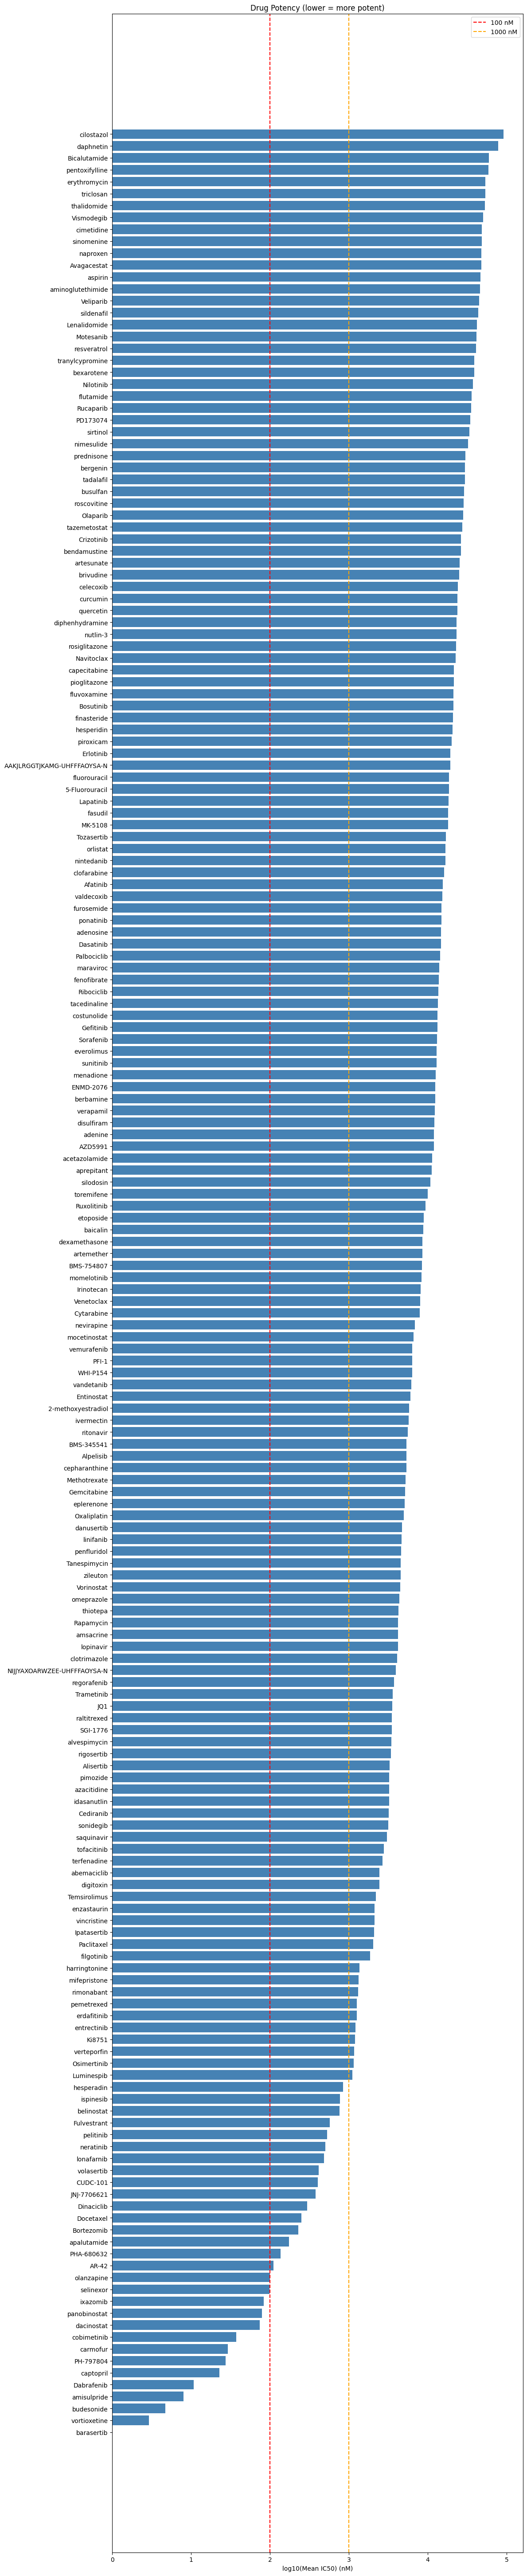

In [4]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, len(ic50_mean) * 0.3))
ax.barh(ic50_mean.index, np.log10(ic50_mean.values), color="steelblue")
ax.set_xlabel("log10(Mean IC50) (nM)")
ax.set_title("Drug Potency (lower = more potent)")
ax.axvline(x=np.log10(100), color="red", linestyle="--", label="100 nM")
ax.axvline(x=np.log10(1000), color="orange", linestyle="--", label="1000 nM")
ax.legend()
plt.tight_layout()
plt.savefig("drug_potency.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
ic50_df = pd.DataFrame(ic50_records)
ic50_df["ic50"] = pd.to_numeric(ic50_df["ic50"], errors="coerce")

# Check what units exist
print(ic50_df["units"].value_counts())

# Keep only nM
ic50_nM = ic50_df[ic50_df["units"] == "nM"]
print(f"\nKept {len(ic50_nM)} / {len(ic50_df)} records (nM only)")

ic50_agg = ic50_nM.groupby("chembl_id")["ic50"].mean().reset_index()
ic50_agg.columns = ["chembl_id", "mean_ic50_nM"]

matched = matched.merge(ic50_agg, on="chembl_id", how="left")
matched.to_csv("matched_drugs_with_ic50.csv", index=False)

units
nM             37791
ug.mL-1          850
10'-8mg/ml         2
ug                 2
10^-4microM        1
mg kg-1            1
molar ratio        1
Name: count, dtype: int64

Kept 37791 / 39073 records (nM only)


In [89]:
smiles_datasets = ["LINCS", "JUMPsm"]
dataset_files = os.listdir("datasets/")
loaded_datasets = {}

for file in dataset_files:
    name = file.replace("_dataset.csv", "")
    df = pd.read_csv(f"datasets/{file}")
    if name in smiles_datasets:
        df["match_col"] = df["iv1"].str.strip().str.lower()
    elif "iv_name" in df.columns:
        df["match_col"] = df["iv_name"].str.strip().str.lower()
    else:
        df["match_col"] = df["iv1"].str.strip().str.lower()
    loaded_datasets[name] = df
    print(f"Loaded {name}")


def get_mean_viability(drug_name, smiles, datasets_str):
    if pd.isna(datasets_str) or datasets_str == "not found":
        return pd.DataFrame()
    drug_norm = drug_name.lower().strip()
    smiles_norm = smiles.lower().strip() if pd.notna(smiles) else None
    records = []
    for dataset in [d.strip() for d in datasets_str.split(",")]:
        if dataset not in loaded_datasets:
            continue
        df = loaded_datasets[dataset]
        key = smiles_norm if dataset in smiles_datasets else drug_norm
        if key is None:
            continue
        subset = df[df["match_col"] == key]
        if len(subset) > 0:
            records.append({"dataset": dataset, "mean_viability": subset["value"].mean(), "n": len(subset)})
    return pd.DataFrame(records)

Loaded Horlbeck
Loaded LINCS
Loaded CTRP
Loaded PRISM
Loaded Shifrut
Loaded SCORE
Loaded JUMPcr
Loaded GDSCcomb
Loaded JUMP
Loaded GDSC
Loaded JUMPsm


In [86]:
from tqdm import tqdm

In [90]:
viability_records = []
for idx, row in tqdm(matched[matched["mean_ic50_nM"].notna()].iterrows()):
    if pd.isna(row["datasets"]) or row["datasets"] == "not found":
        continue
    viability = get_mean_viability(row["drug"], row["smiles_norm"], row["datasets"])
    if len(viability) > 0:
        viability_records.append({
            "drug": row["drug"],
            "chembl_id": row["chembl_id"],
            "mean_ic50_nM": row["mean_ic50_nM"],
            "mean_viability": viability["mean_viability"].mean(),
            "n_datasets": len(viability)
        })

viability_df = pd.DataFrame(viability_records)
print(f"Drugs with both IC50 and viability: {len(viability_df)}")
print(viability_df.head())
viability_df.to_csv("ic50_viability.csv", index=False)

271it [10:19,  2.29s/it]

Drugs with both IC50 and viability: 260
          drug      chembl_id  mean_ic50_nM  mean_viability  n_datasets
0  Osimertinib  CHEMBL3353410   8691.816808        0.552800           2
1   Trametinib  CHEMBL2103875   1641.710172        0.501830           5
2   Paclitaxel   CHEMBL428647  40115.570530        0.454016           5
3    Docetaxel  CHEMBL3545252   1496.195653        0.445781           5
4  Palbociclib   CHEMBL189963  36734.111876        0.464667           4


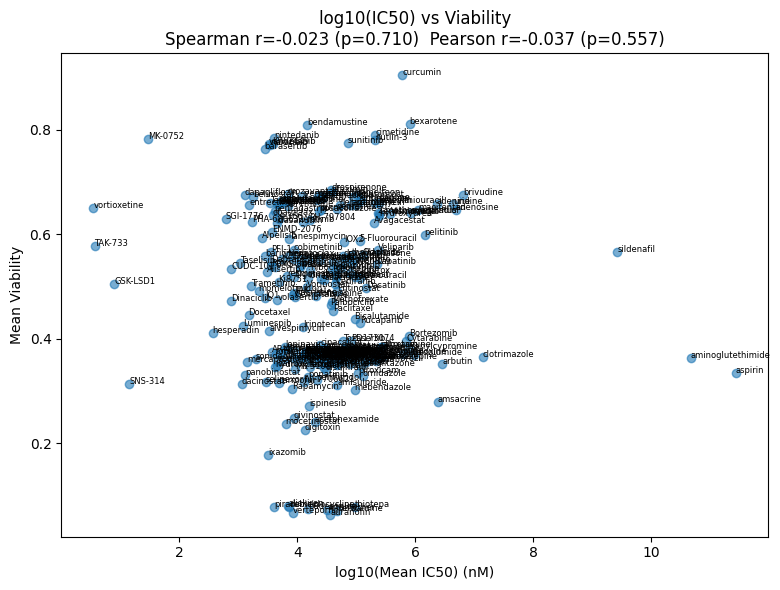

In [93]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Drop any NaN
plot_df = viability_df[["drug", "mean_ic50_nM", "mean_viability"]].dropna()
plot_df["log_ic50"] = np.log10(plot_df["mean_ic50_nM"])

spearman_r, spearman_p = stats.spearmanr(plot_df["log_ic50"], plot_df["mean_viability"])
pearson_r, pearson_p = stats.pearsonr(plot_df["log_ic50"], plot_df["mean_viability"])

plt.figure(figsize=(8, 6))
plt.scatter(plot_df["log_ic50"], plot_df["mean_viability"], alpha=0.6)
for _, row in plot_df.iterrows():
    plt.annotate(row["drug"], (row["log_ic50"], row["mean_viability"]), fontsize=6)

plt.xlabel("log10(Mean IC50) (nM)")
plt.ylabel("Mean Viability")
plt.title(f"log10(IC50) vs Viability\nSpearman r={spearman_r:.3f} (p={spearman_p:.3f})  Pearson r={pearson_r:.3f} (p={pearson_p:.3f})")
plt.tight_layout()
plt.savefig("ic50_viability_corr.png", dpi=150)
plt.show()


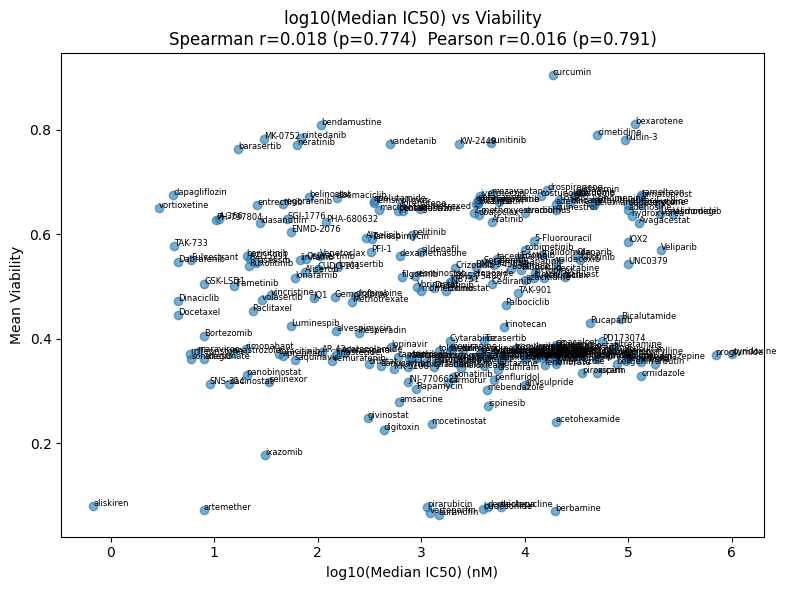

In [94]:
ic50_agg_median = ic50_nM.groupby("chembl_id")["ic50"].median().reset_index()
ic50_agg_median.columns = ["chembl_id", "median_ic50_nM"]

plot_df = viability_df.merge(ic50_agg_median, on="chembl_id", how="left").dropna(subset=["median_ic50_nM", "mean_viability"])
plot_df["log_ic50"] = np.log10(plot_df["median_ic50_nM"])

spearman_r, spearman_p = stats.spearmanr(plot_df["log_ic50"], plot_df["mean_viability"])
pearson_r, pearson_p = stats.pearsonr(plot_df["log_ic50"], plot_df["mean_viability"])

plt.figure(figsize=(8, 6))
plt.scatter(plot_df["log_ic50"], plot_df["mean_viability"], alpha=0.6)
for _, row in plot_df.iterrows():
    plt.annotate(row["drug"], (row["log_ic50"], row["mean_viability"]), fontsize=6)

plt.xlabel("log10(Median IC50) (nM)")
plt.ylabel("Mean Viability")
plt.title(f"log10(Median IC50) vs Viability\nSpearman r={spearman_r:.3f} (p={spearman_p:.3f})  Pearson r={pearson_r:.3f} (p={pearson_p:.3f})")
plt.tight_layout()
plt.savefig("ic50_viability_corr.png", dpi=150)
plt.show()

In [117]:
from prophet import Prophet
import torch
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
iv_emb_path, _ = Prophet.download_embeddings()

ImportError: Numba needs NumPy 1.24 or less

In [108]:
model = Prophet.from_pretrained("base", split="cell_lines", fold=0, seed=110)
model.model.eval()

🔄 Downloading base model from HuggingFace Hub...
   Configuration: split=cell_lines, fold=0, seed=110
Successfully downloaded base model: epoch=29-step=45360.ckpt
  Configuration: split=unseen_cell_lines, fold=0, seed=110
  Model file: /root/.cache/prophet/base_cell_lines_fold0_seed110/datasets--theislab--Prophet/snapshots/7d8b27edeaab117af851e3f5625a018b0f45fa35/base_pretrained/unseen_cell_lines_fold_0/seed_110/epoch=29-step=45360.ckpt
Learning rate set to 1e-05


TransformerPredictor(
  (learnable_embedding): Embedding(1000, 512, max_norm=0.5)
  (embedding_dropout): Dropout(p=0.2, inplace=False)
  (gene_net): Sequential(
    (0): Linear(in_features=1219, out_features=512, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=512, bias=True)
  )
  (drug_net): Sequential(
    (0): Linear(in_features=1219, out_features=512, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=512, bias=True)
  )
  (cl_net): Sequential(
    (0): Linear(in_features=300, out_features=512, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=512, bias=True)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-7): 8 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQu

In [97]:
iv_emb = pd.read_csv(iv_emb_path, index_col=0)
iv_emb.index = iv_emb.index.str.strip().str.lower()

In [102]:
iv_emb_filtered = iv_emb[iv_emb.index.isin(drug_names)]
iv_emb_filtered = iv_emb_filtered[~iv_emb_filtered.index.duplicated(keep="first")]
iv_emb_filtered = iv_emb_filtered.drop(columns=["type"], errors="ignore")
print(f"Found embeddings for {len(iv_emb_filtered)} / {len(drug_names)} drugs")

Found embeddings for 258 / 260 drugs


In [104]:
print(iv_emb_filtered.dtypes.value_counts())
print(iv_emb_filtered.select_dtypes(exclude="number").columns.tolist())

float64    1219
object        1
Name: count, dtype: int64
['smiles']


In [105]:
iv_emb_filtered = iv_emb_filtered.select_dtypes(include="number")

In [106]:
emb_matrix = torch.tensor(iv_emb_filtered.values, dtype=torch.float32)

In [110]:
with torch.no_grad():
    prophet_emb = model.model.drug_net(emb_matrix).numpy()

prophet_emb_df = pd.DataFrame(prophet_emb, index=iv_emb_filtered.index)

In [126]:
viability_df.to_csv("ic50_viability.csv", index=False)
ic50_df.to_csv("ic50_raw.csv", index=False)
plot_df.to_csv("plot_df.csv", index=False)
prophet_emb_df.to_csv("prophet_emb.csv")
iv_emb_filtered.to_csv("iv_emb_filtered.csv")

/usr/local/lib/python3.10/dist-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 512 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)
/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


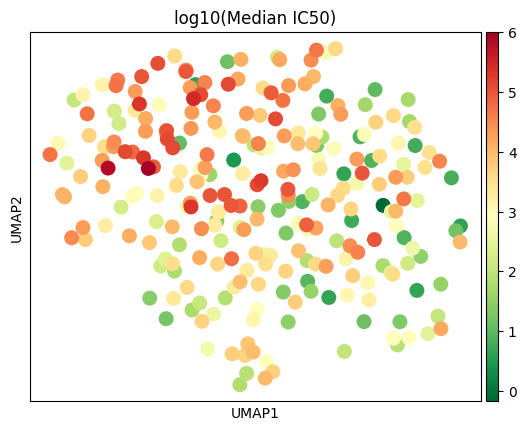

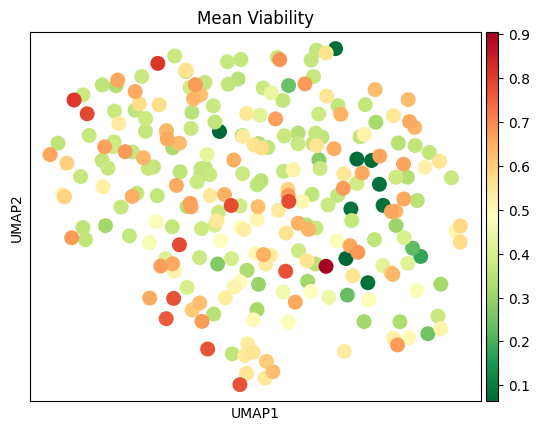

In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd

prophet_emb_df = pd.read_csv("prophet_emb.csv", index_col=0)
plot_df = pd.read_csv("plot_df.csv")

# Build AnnData
adata = ad.AnnData(X=prophet_emb_df.values)
adata.obs_names = prophet_emb_df.index

# Add metadata
meta = plot_df.set_index(plot_df["drug"].str.lower().str.strip())
adata.obs["log_ic50"] = meta.loc[adata.obs_names, "log_ic50"].values
adata.obs["mean_viability"] = meta.loc[adata.obs_names, "mean_viability"].values

# UMAP
sc.pp.neighbors(adata)
sc.tl.umap(adata)

# Plot
sc.pl.umap(adata, color="log_ic50", cmap="RdYlGn_r", title="log10(Median IC50)")
sc.pl.umap(adata, color="mean_viability", cmap="RdYlGn_r", title="Mean Viability")